# Image Segmentation on BUSI with U-Net (PyTorch)

This notebook is a **highly explained, step-by-step tutorial** for beginners who want to learn **image segmentation** using a **U-Net** on **BUSI** data.

## What is BUSI?
**BUSI** stands for **Breast Ultrasound Images**.

In this notebook, the goal is to segment the lesion region:
- **input** = ultrasound image
- **output** = pixel-level mask

This is different from image classification:
- classification gives **one label per image**
- segmentation gives **one label per pixel**

## What this notebook teaches
- what image segmentation is
- how masks work
- how to load ultrasound images and masks
- how to build a U-Net in PyTorch
- how tensor shapes change inside U-Net
- how to train for segmentation
- how to evaluate with Dice and IoU
- how to visualize predictions
- how to modify the architecture

## Important note about BUSI folder structure
This notebook assumes a local dataset structure like this:

```text
BUSI/
    benign/
        benign (1).png
        benign (1)_mask.png
        benign (2).png
        benign (2)_mask.png
    malignant/
        malignant (1).png
        malignant (1)_mask.png
    normal/
        normal (1).png
        normal (1)_mask.png
```

Many BUSI distributions follow a similar naming pattern:
- image file: `something.png`
- mask file: `something_mask.png`

If your BUSI folder is slightly different, you only need to adjust the dataset path logic.

In [1]:
# Core imports
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0


## 1. Reproducibility and device setup

Deep learning contains randomness, so we set a seed.

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Explain the segmentation task

For segmentation:
- input image shape is typically `[B, C, H, W]`
- output mask shape is typically `[B, 1, H, W]`

Each pixel in the mask tells us whether that pixel belongs to the target object.

For binary lesion segmentation:
- `0` = background
- `1` = lesion

So the model does **pixel-wise classification**.

## 3. Point to your BUSI dataset folder

Update the path below to the place where your BUSI dataset is stored on your computer.

In [4]:
# Change this path to your local BUSI dataset folder
DATA_DIR = Path("./BUSI")

print("Dataset path exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset path exists: True
Dataset path: /Users/josoga2/Documents/wale_docs/phd/HB/py/basic_ml/08_CNN/BUSI


## 4. Build a dataset class

This dataset class:
- finds image files
- finds their matching masks
- resizes them to a consistent size
- converts them to tensors
- makes sure masks are binary

### Why resize?
Neural networks usually expect all images in a batch to have the same shape.

### Why nearest-neighbor for masks?
For masks, we do **not** want interpolation that creates blurry label values.

In [5]:
class BUSISegmentationDataset(Dataset):
    def __init__(self, root_dir, image_size=(256, 256)):
        self.root_dir = Path(root_dir)
        self.image_size = image_size
        self.samples = []

        valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

        for class_dir in self.root_dir.iterdir():
            if not class_dir.is_dir():
                continue

            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() not in valid_exts:
                    continue

                if "_mask" in img_path.stem.lower():
                    continue

                mask_candidate = img_path.with_name(f"{img_path.stem}_mask{img_path.suffix}")

                if mask_candidate.exists():
                    self.samples.append((img_path, mask_candidate, class_dir.name))

        self.samples = sorted(self.samples)

        self.image_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
        ])

        self.mask_resize = transforms.Resize(
            self.image_size,
            interpolation=transforms.InterpolationMode.NEAREST
        )

        if len(self.samples) == 0:
            print("Warning: no image-mask pairs found. Check your BUSI path and file naming.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path, class_name = self.samples[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.image_transform(image)

        mask = self.mask_resize(mask)
        mask = np.array(mask, dtype=np.float32)
        mask = (mask > 0).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0)

        return {
            "image": image,
            "mask": mask,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "class_name": class_name,
        }

## 5. Create the dataset and inspect its size

In [6]:
dataset = BUSISegmentationDataset(DATA_DIR, image_size=(256, 256))
print("Number of image-mask pairs:", len(dataset))

Number of image-mask pairs: 780


## 6. Visualize a few examples

Always inspect the data first.

We want to see:
- the ultrasound image
- the binary mask
- the lesion overlaid on the image

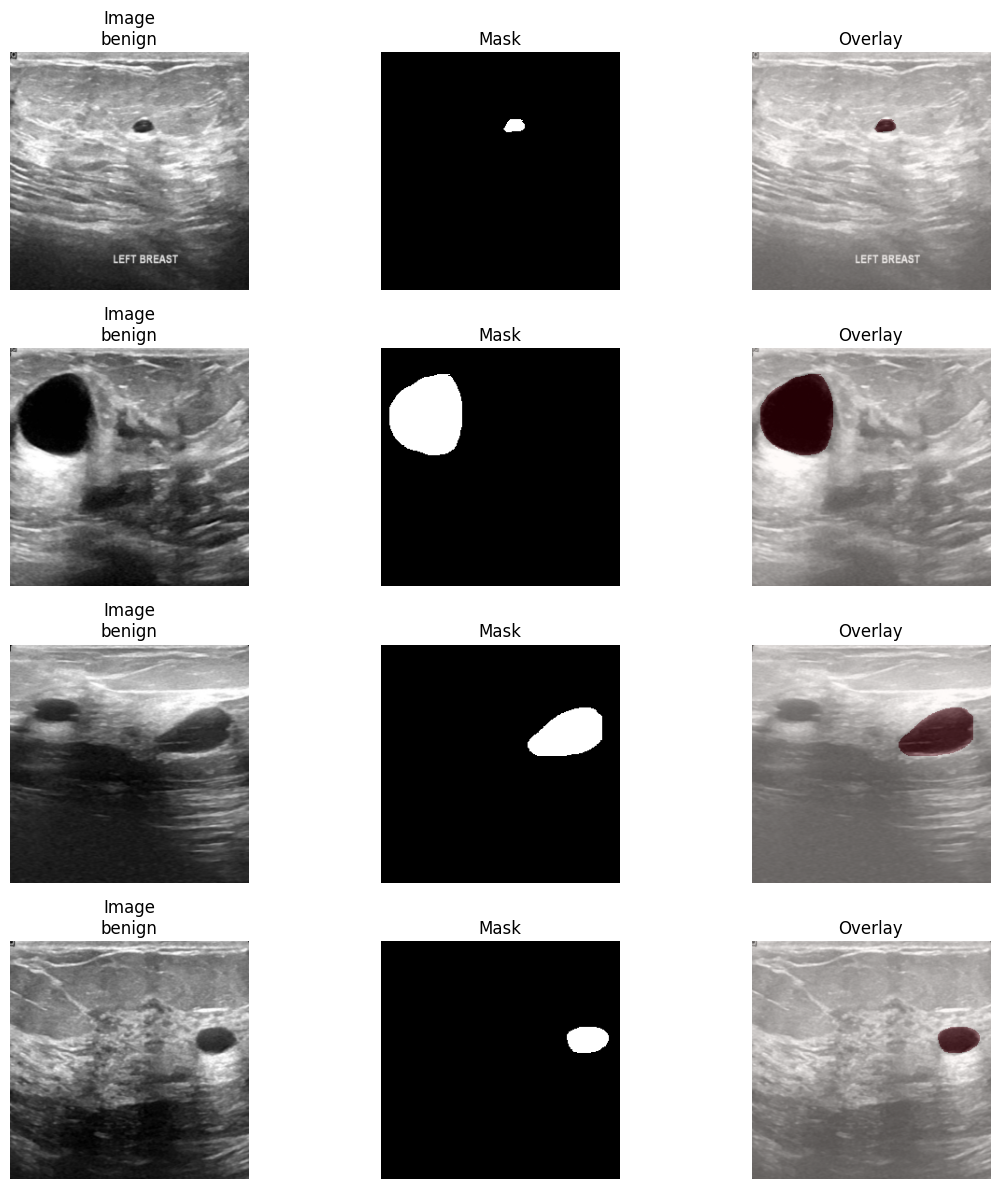

In [7]:
def show_dataset_samples(dataset, num_samples=4):
    num_samples = min(num_samples, len(dataset))
    if num_samples == 0:
        print("Dataset is empty. Check your BUSI path.")
        return

    plt.figure(figsize=(12, 3 * num_samples))

    for i in range(num_samples):
        sample = dataset[i]
        image = sample["image"].permute(1, 2, 0).numpy()
        mask = sample["mask"].squeeze(0).numpy()
        class_name = sample["class_name"]

        plt.subplot(num_samples, 3, 3*i + 1)
        plt.imshow(image)
        plt.title(f"Image\n{class_name}")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3*i + 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3*i + 3)
        plt.imshow(image)
        plt.imshow(mask, alpha=0.35, cmap="Reds")
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_dataset_samples(dataset, num_samples=4)

## 7. Train / validation / test split

We split the dataset into:
- train
- validation
- test

### Why?
- train: update model weights
- validation: monitor performance while developing
- test: final unbiased evaluation

In [8]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 546
Val size: 117
Test size: 117


## 8. DataLoaders

For notebooks on macOS, `num_workers=0` is usually the safest choice.

Each batch contains:
- images: `[B, 3, H, W]`
- masks: `[B, 1, H, W]`

In [9]:
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
images = batch["image"]
masks = batch["mask"]

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])


## 9. U-Net intuition

U-Net has two main paths:

### Contracting path (encoder)
This path:
- uses convolutions
- extracts features
- reduces spatial size
- learns *what* is in the image

### Expanding path (decoder)
This path:
- upsamples features
- restores spatial detail
- learns *where* the object is

### Skip connections
These connect encoder features to decoder features.

Why?
Because segmentation needs:
- **context** from deep layers
- **fine detail** from early layers

This is the key idea behind U-Net.

## 10. Build U-Net step by step

We will define small building blocks first:
- double convolution block
- down block
- up block
- full U-Net

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

### What `DoubleConv` does
It applies:
- convolution
- ReLU
- convolution
- ReLU

This helps the model learn richer image features before moving on.

In [11]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return x

### What `Down` does
It performs:
1. max pooling -> reduce height and width by half
2. double convolution -> learn new features

In [12]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x_decoder, x_encoder):
        x_decoder = self.up(x_decoder)

        diff_y = x_encoder.size(2) - x_decoder.size(2)
        diff_x = x_encoder.size(3) - x_decoder.size(3)

        x_decoder = F.pad(
            x_decoder,
            [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2]
        )

        x = torch.cat([x_encoder, x_decoder], dim=1)
        x = self.conv(x)
        return x

### What `Up` does
It performs:
1. transpose convolution -> increase spatial size
2. concatenate with encoder feature map (skip connection)
3. double convolution -> combine detail + context

In [13]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits

## 11. Create the model

In [14]:
model = UNet(in_channels=3, out_channels=1).to(device)
model

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
  )
  (down2): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1

## 12. Inspect tensor shapes inside U-Net

This is extremely useful for understanding architecture flow.

In [15]:
x = images[:2].to(device)

with torch.no_grad():
    x1 = model.inc(x)
    print("x1:", x1.shape)

    x2 = model.down1(x1)
    print("x2:", x2.shape)

    x3 = model.down2(x2)
    print("x3:", x3.shape)

    x4 = model.down3(x3)
    print("x4:", x4.shape)

    x5 = model.down4(x4)
    print("x5:", x5.shape)

    y = model.up1(x5, x4)
    print("up1:", y.shape)

    y = model.up2(y, x3)
    print("up2:", y.shape)

    y = model.up3(y, x2)
    print("up3:", y.shape)

    y = model.up4(y, x1)
    print("up4:", y.shape)

    logits = model.outc(y)
    print("logits:", logits.shape)

x1: torch.Size([2, 64, 256, 256])
x2: torch.Size([2, 128, 128, 128])
x3: torch.Size([2, 256, 64, 64])
x4: torch.Size([2, 512, 32, 32])
x5: torch.Size([2, 1024, 16, 16])
up1: torch.Size([2, 512, 32, 32])
up2: torch.Size([2, 256, 64, 64])
up3: torch.Size([2, 128, 128, 128])
up4: torch.Size([2, 64, 256, 256])
logits: torch.Size([2, 1, 256, 256])


## 13. Loss functions for segmentation

For binary segmentation, a common starting choice is:
- **BCEWithLogitsLoss**

Why "with logits"?
Because the model output is raw scores, not probabilities yet.

We will also define Dice and IoU metrics.

In [16]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [17]:
def dice_coefficient_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    total = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    union = total - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

## 14. Training and evaluation functions

We track:
- loss
- Dice
- IoU

### Why Dice and IoU matter
In segmentation, accuracy can be misleading because background often dominates the image.

Dice and IoU focus on overlap between:
- predicted mask
- true mask

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    total_batches = 0

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_coefficient_from_logits(logits.detach(), masks)
        running_iou += iou_from_logits(logits.detach(), masks)
        total_batches += 1

    return {
        "loss": running_loss / total_batches,
        "dice": running_dice / total_batches,
        "iou": running_iou / total_batches
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    total_batches = 0

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        running_loss += loss.item()
        running_dice += dice_coefficient_from_logits(logits, masks)
        running_iou += iou_from_logits(logits, masks)
        total_batches += 1

    return {
        "loss": running_loss / total_batches,
        "dice": running_dice / total_batches,
        "iou": running_iou / total_batches
    }

## 15. Train the U-Net

Start with a modest number of epochs for teaching.

In [19]:
num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
}

best_val_dice = -1
best_state = None

for epoch in range(1, num_epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_metrics["dice"])
    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_metrics["iou"])

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Train Dice: {train_metrics['dice']:.4f} | "
        f"Val Dice: {val_metrics['dice']:.4f} | "
        f"Train IoU: {train_metrics['iou']:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model based on validation Dice.")

Epoch 01 | Train loss: 0.4617 | Val loss: 0.2459 | Train Dice: 0.1210 | Val Dice: 0.2267 | Train IoU: 0.1065 | Val IoU: 0.2267
Epoch 02 | Train loss: 0.2904 | Val loss: 0.2254 | Train Dice: 0.1630 | Val Dice: 0.2267 | Train IoU: 0.1630 | Val IoU: 0.2267
Epoch 03 | Train loss: 0.2389 | Val loss: 0.1989 | Train Dice: 0.1630 | Val Dice: 0.2267 | Train IoU: 0.1630 | Val IoU: 0.2267
Epoch 04 | Train loss: 0.2304 | Val loss: 0.2111 | Train Dice: 0.1576 | Val Dice: 0.2267 | Train IoU: 0.1576 | Val IoU: 0.2267
Epoch 05 | Train loss: 0.2268 | Val loss: 0.1862 | Train Dice: 0.1576 | Val Dice: 0.2267 | Train IoU: 0.1576 | Val IoU: 0.2267
Epoch 06 | Train loss: 0.2107 | Val loss: 0.1873 | Train Dice: 0.1630 | Val Dice: 0.2267 | Train IoU: 0.1630 | Val IoU: 0.2267
Epoch 07 | Train loss: 0.2098 | Val loss: 0.1895 | Train Dice: 0.1572 | Val Dice: 0.1527 | Train IoU: 0.1553 | Val IoU: 0.1069
Epoch 08 | Train loss: 0.2085 | Val loss: 0.1900 | Train Dice: 0.1689 | Val Dice: 0.2441 | Train IoU: 0.1568 | 

## 16. Plot learning curves

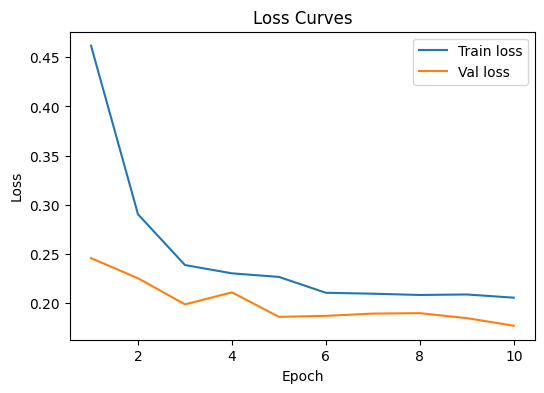

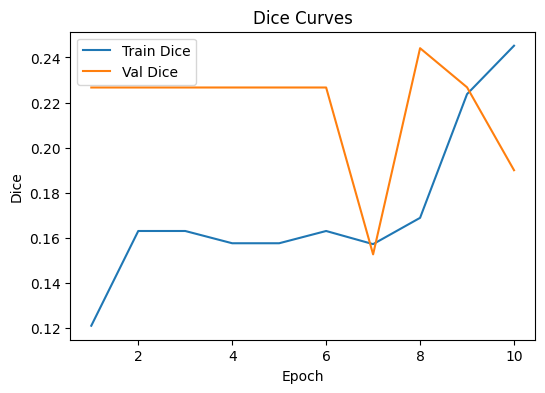

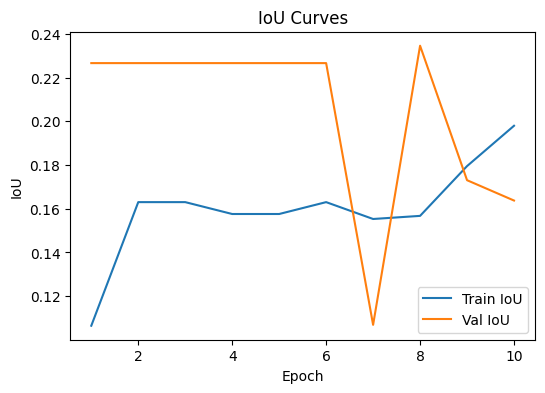

In [20]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_dice"], label="Train Dice")
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Dice Curves")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_iou"], label="Train IoU")
plt.plot(epochs, history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU Curves")
plt.legend()
plt.show()

## 17. Test-set evaluation

In [21]:
test_metrics = evaluate(model, test_loader, criterion, device)

print("Test loss:", round(test_metrics["loss"], 4))
print("Test Dice:", round(test_metrics["dice"], 4))
print("Test IoU:", round(test_metrics["iou"], 4))

Test loss: 0.2064
Test Dice: 0.1683
Test IoU: 0.1676


## 18. Visualize predictions

This is one of the most important parts of a segmentation notebook.

We want to compare:
- original image
- ground-truth mask
- predicted mask
- overlay

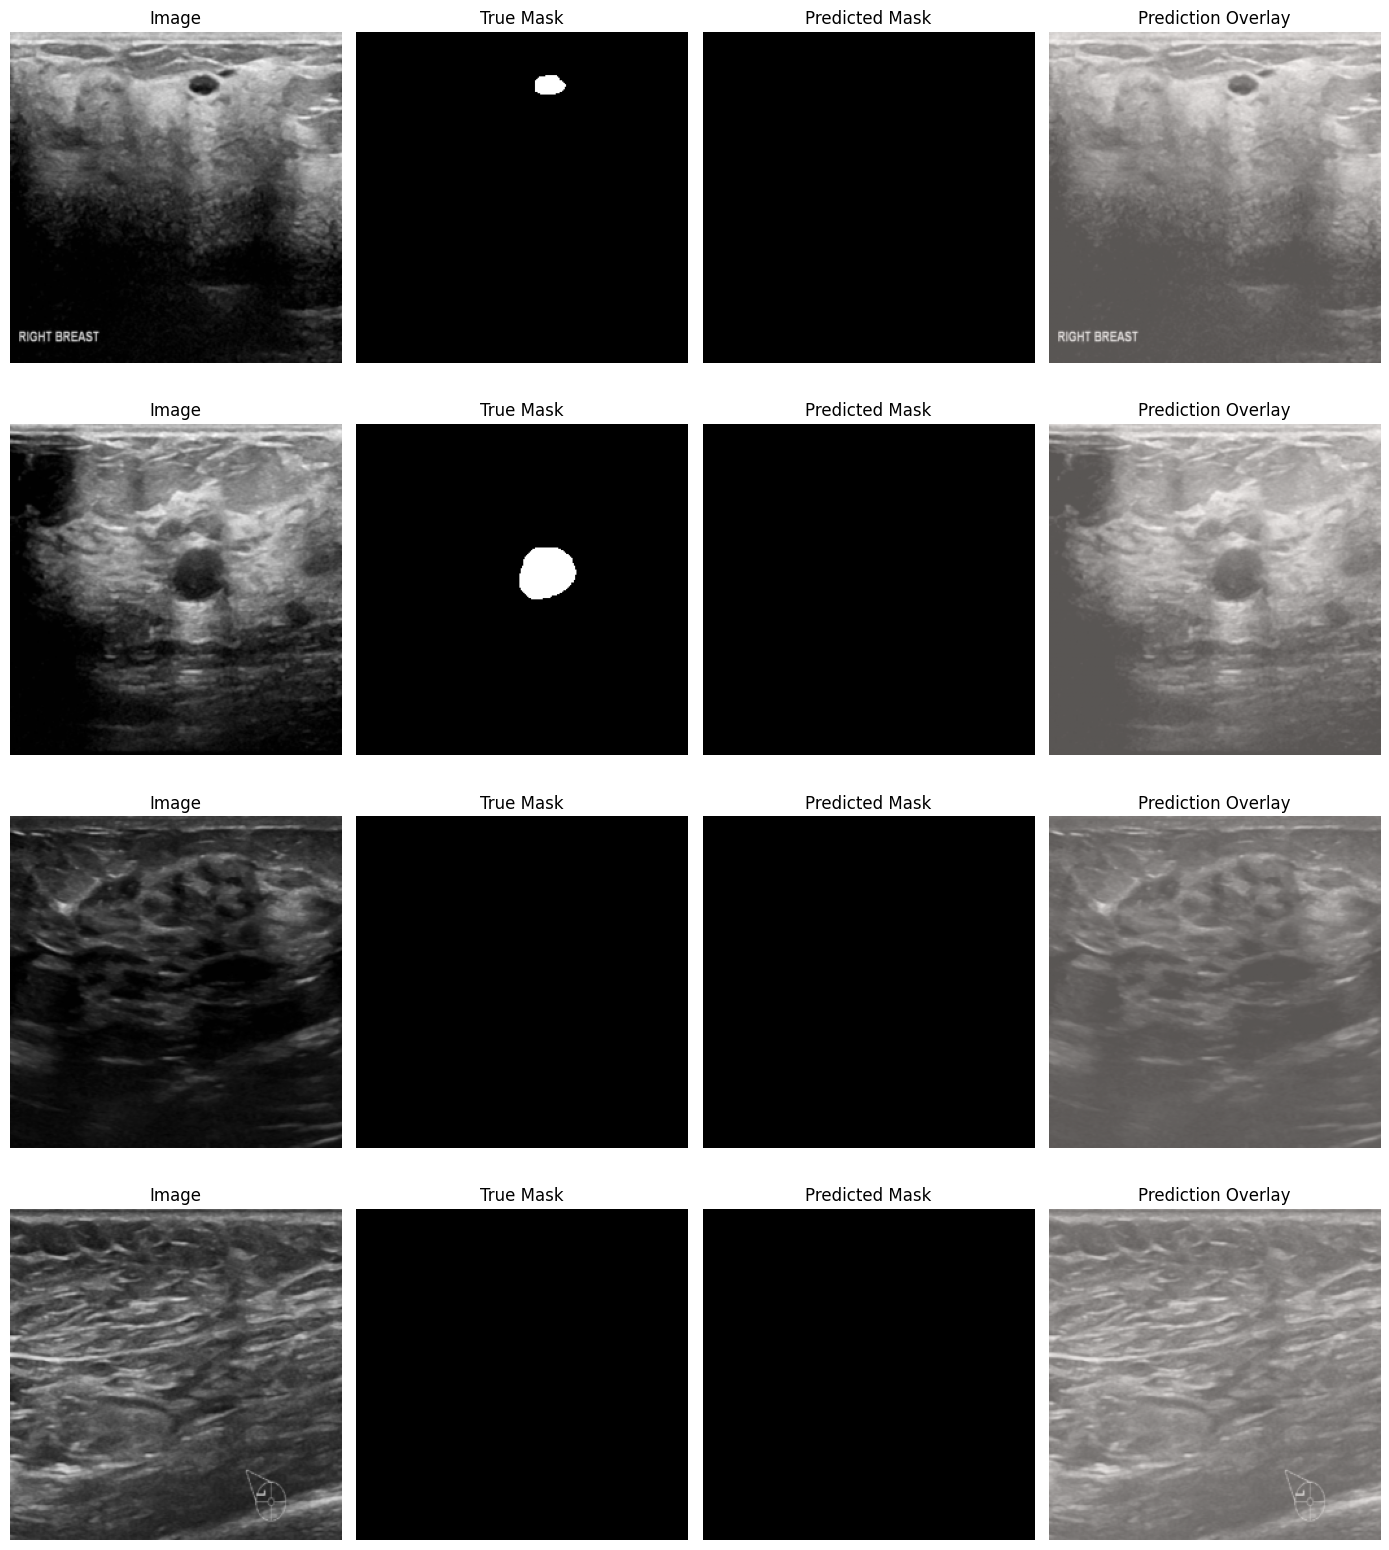

In [22]:
@torch.no_grad()
def show_predictions(model, dataset, num_samples=4, threshold=0.5):
    model.eval()
    num_samples = min(num_samples, len(dataset))
    if num_samples == 0:
        print("Dataset is empty.")
        return

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(14, 4 * num_samples))

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        image = sample["image"].unsqueeze(0).to(device)
        true_mask = sample["mask"].squeeze(0).cpu().numpy()

        logits = model(image)
        probs = torch.sigmoid(logits)
        pred_mask = (probs > threshold).float().squeeze().cpu().numpy()

        img_np = sample["image"].permute(1, 2, 0).cpu().numpy()

        plt.subplot(num_samples, 4, 4*row + 1)
        plt.imshow(img_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 4, 4*row + 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 4, 4*row + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.subplot(num_samples, 4, 4*row + 4)
        plt.imshow(img_np)
        plt.imshow(pred_mask, alpha=0.35, cmap="Reds")
        plt.title("Prediction Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, num_samples=4)

## 19. Important beginner interpretation points

When you look at segmentation results, ask:
1. Does the predicted mask cover the lesion?
2. Is the mask too small?
3. Is the mask too large?
4. Does the model miss lesion boundaries?
5. Does the model confuse noise with lesion area?

This helps students move from:
- "the code runs"
to
- "I understand the model behavior"

## 20. How to modify the architecture

This is where students learn to think like model builders.

### A. Reduce model size
U-Net is strong, but sometimes heavy.
You can reduce channels:
- 64 -> 32
- 128 -> 64

This makes training faster.

### B. Add normalization
You can add:
- `nn.BatchNorm2d(...)`

This can sometimes stabilize training.

### C. Add dropout
You can add dropout in deeper layers to reduce overfitting.

### D. Use augmentation
Very important in medical imaging.

### E. Change the loss
Common choices:
- BCE
- Dice loss
- BCE + Dice loss

In [ ]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.inc = DoubleConv(in_channels, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        self.up4 = Up(64, 32)

        self.outc = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)

small_model = SmallUNet().to(device)
small_model

## 21. Optional extension: data augmentation

For segmentation, image and mask must undergo the **same geometric transformation**.

That is very important.

If you rotate the image, you must also rotate the mask by exactly the same amount.

In production code, people often use libraries like:
- Albumentations
- MONAI

In [ ]:
print("For a beginner notebook, augmentation is kept separate for simplicity.")
print("A strong next step is to implement paired transforms for image and mask.")

## 22. Optional extension: Dice loss

Dice is not only a metric. It can also be used as a loss.

In [ ]:
def dice_loss_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss_from_logits(logits, targets)
    return bce + dice

print("You can replace BCEWithLogitsLoss with bce_dice_loss for experiments.")

## 23. Suggested student exercises

1. Train for more epochs and compare Dice.
2. Try `SmallUNet` and compare speed vs performance.
3. Replace BCE loss with BCE + Dice loss.
4. Add BatchNorm to `DoubleConv`.
5. Reduce image size to 128 x 128 and compare results.
6. Add paired augmentation for image and mask.
7. Compare predictions on benign vs malignant samples.

## 24. Final summary

In this notebook, you learned how to:
- load BUSI breast ultrasound images and masks
- understand segmentation as pixel-wise prediction
- build U-Net step by step
- track tensor shapes
- train a segmentation model
- evaluate with Dice and IoU
- visualize predicted masks
- think about architecture modifications

### Core idea to remember
U-Net works well because it combines:
- **deep context**
- **fine spatial detail**